# Panel cumulative local projections: CPI on xi x oil

This notebook estimates cumulative panel local projections using quarterly CPI inflation.

Conventions used here:

- the dependent variable at horizon `h` is the cumulative sum of quarterly CPI inflation from `t` through `t+h`,
- lags of `y` are lags of the underlying quarterly CPI inflation series, not lags of the cumulative target,
- if enabled, annual CPI can replace the cumulative quarterly target only for full calendar-year windows.


In [46]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [ ]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]
regression_controls = ["exchange_rate", "output_gap", "policy_rate"]
#regression_controls = ["oil_pct_change", "exchange_rate"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_time_fe = True
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
use_annual_cpi_for_full_year_horizons = False
lag_xi_by_one_year_for_xi_x_oil = True

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
include_country_fe: True
include_time_fe: True
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']
use_annual_cpi_for_full_year_horizons: False
lag_xi_by_one_year_for_xi_x_oil: True


In [48]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [49]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,4470,40,1995,2022,27.95,1995-Q1,2022-Q4,111.75


In [50]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 4470


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,...,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AUS,1995,1995-Q1,7980,0.021698,0.043415,NaN,0.015924,0.008404,-0.002764,...,0.042395,0.050028,0.053059,0.060612,0.063610,0.065105,0.066597,0.063617,0.059133,0.062136
1,AUS,1995,1995-Q2,7981,0.021698,0.051642,NaN,0.014106,0.028409,-0.007747,...,0.034105,0.037135,0.044688,0.047686,0.049181,0.050674,0.047693,0.043209,0.046212,0.049206
2,AUS,1995,1995-Q3,7982,0.021698,-0.097255,NaN,0.012365,-0.017450,0.005223,...,0.023029,0.030582,0.033580,0.035075,0.036567,0.033587,0.029103,0.032105,0.035099,0.041070
3,AUS,1995,1995-Q4,7983,0.021698,0.026433,NaN,0.007634,-0.010554,-0.004938,...,0.018217,0.021215,0.022710,0.024203,0.021222,0.016738,0.019741,0.022735,0.028705,0.030188
4,AUS,1996,1996-Q1,7984,0.024256,0.079017,0.001714,0.003030,-0.010226,0.000280,...,0.013582,0.015076,0.016569,0.013588,0.009104,0.012107,0.015101,0.021071,0.022555,0.026999


In [51]:
cum_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
panel_df_model[["country", "period", "cpi_pct_change", *cum_cols]].head(12)


,country,period,cpi_pct_change,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AUS,1995-Q1,0.015924,0.015924,0.030030,0.042395,0.050028,0.053059,0.060612,0.063610,0.065105,0.066597,0.063617,0.059133,0.062136
1,AUS,1995-Q2,0.014106,0.014106,0.026471,0.034105,0.037135,0.044688,0.047686,0.049181,0.050674,0.047693,0.043209,0.046212,0.049206
2,AUS,1995-Q3,0.012365,0.012365,0.019998,0.023029,0.030582,0.033580,0.035075,0.036567,0.033587,0.029103,0.032105,0.035099,0.041070
3,AUS,1995-Q4,0.007634,0.007634,0.010664,0.018217,0.021215,0.022710,0.024203,0.021222,0.016738,0.019741,0.022735,0.028705,0.030188
4,AUS,1996-Q1,0.003030,0.003030,0.010583,0.013582,0.015076,0.016569,0.013588,0.009104,0.012107,0.015101,0.021071,0.022555,0.026999
5,AUS,1996-Q2,0.007553,0.007553,0.010551,0.012046,0.013539,0.010558,0.006074,0.009077,0.012071,0.018041,0.019525,0.023969,0.023969
6,AUS,1996-Q3,0.002998,0.002998,0.004493,0.005986,0.003005,-0.001479,0.001524,0.004518,0.010488,0.011972,0.016416,0.016416,0.020841
7,AUS,1996-Q4,0.001495,0.001495,0.002987,0.000007,-0.004477,-0.001474,0.001519,0.007490,0.008973,0.013418,0.013418,0.017843,0.026653
8,AUS,1997-Q1,0.001493,0.001493,-0.001488,-0.005972,-0.002969,0.000025,0.005995,0.007478,0.011923,0.011923,0.016348,0.025158,0.030981
9,AUS,1997-Q2,-0.002981,-0.002981,-0.007465,-0.004462,-0.001468,0.004502,0.005986,0.010430,0.010430,0.014855,0.023666,0.029488,0.038171


In [52]:
irf_df, coef_df, models = lp.fit_cumulative_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value 

,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,-0.056103,0.073580,-0.762472,0.445779,-0.200317,0.088112,3010.0,39
1,1,xi_x_oil,-0.099781,0.078634,-1.268916,0.204471,-0.253901,0.054340,3010.0,39
2,2,xi_x_oil,-0.124152,0.105003,-1.182372,0.237058,-0.329954,0.081649,3010.0,39
3,3,xi_x_oil,-0.089650,0.085921,-1.043400,0.296763,-0.258051,0.078752,3010.0,39
4,4,xi_x_oil,-0.094771,0.110761,-0.855635,0.392200,-0.311860,0.122317,3010.0,39
5,5,xi_x_oil,-0.164456,0.140221,-1.172835,0.240862,-0.439285,0.110372,3010.0,39
6,6,xi_x_oil,-0.161069,0.187671,-0.858255,0.390752,-0.528897,0.206759,3010.0,39
7,7,xi_x_oil,-0.163223,0.181059,-0.901492,0.367327,-0.518093,0.191646,3010.0,39
8,8,xi_x_oil,-0.240958,0.196970,-1.223322,0.221208,-0.627012,0.145097,3010.0,39
9,9,xi_x_oil,-0.306905,0.235370,-1.303927,0.192258,-0.768221,0.154411,3010.0,39


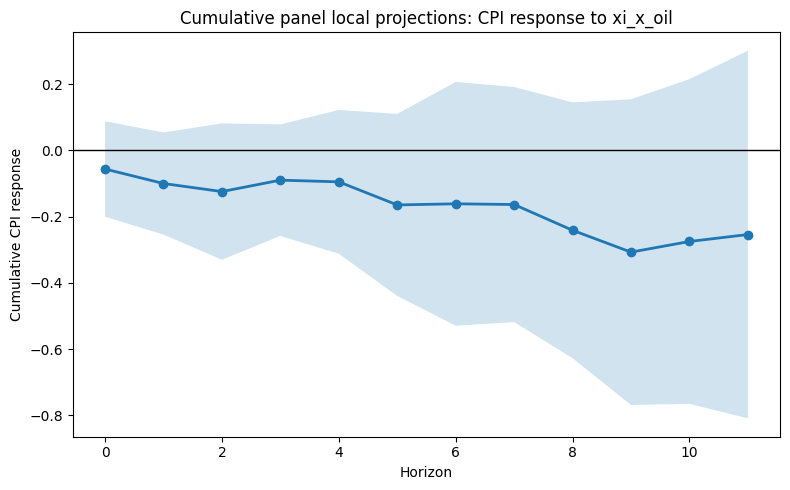

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, title="Cumulative panel local projections: CPI response to xi_x_oil", ax=ax)
ax.set_ylabel("Cumulative CPI response")
plt.tight_layout()
plt.show()


In [54]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                            OLS Regression Results                            
Dep. Variable:          cum_cpi_lead0   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     46.37
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.88e-24
Time:                        17:16:54   Log-Likelihood:                 11043.
No. Observations:                3010   AIC:                        -2.179e+04
Df Residuals:                    2862   BIC:                        -2.090e+04
Df Model:                         147                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0036    